In [1]:
import pandas as pd
import matplotlib.pyplot as plt
def graphModel(csv_file, top=None):

    # Load CSV
    df = pd.read_csv(csv_file)

    # ensure numeric (handles empty strings)
    cols = ["train_loss", "val_loss", "val_next_token_acc", "test_final_word_acc"]
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    # ---- MIN LOSSES ----
    min_train_loss = df["train_loss"].min()
    min_val_loss = df["val_loss"].min()

    epoch_min_train = df.loc[df["train_loss"].idxmin(), "epoch"]
    epoch_min_val = df.loc[df["val_loss"].idxmin(), "epoch"]

    # ---- MAX ACCURACIES ----
    max_next_token_acc = df["val_next_token_acc"].max()
    max_final_word_acc = df["test_final_word_acc"].max()

    epoch_max_next = df.loc[df["val_next_token_acc"].idxmax(), "epoch"]
    epoch_max_final = df.loc[df["test_final_word_acc"].idxmax(), "epoch"]

    # Convert columns to numeric, turning empty strings into NaN
    for col in [
        "epoch",
        "train_loss",
        "val_loss",
        "val_next_token_acc",
        "test_final_word_acc",
    ]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # Create figure
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Left Y-axis (losses)
    if "train_loss" in df.columns:
        ax1.plot(
            df["epoch"], 
            df["train_loss"], 
            label="Train Loss (Min: "+str(f"{min_train_loss:.3f}")+")",
            color="red"
        )

    if "val_loss" in df.columns:
        ax1.plot(
            df["epoch"], 
            df["val_loss"], 
            label="Val Loss (Min: "+str(f"{min_val_loss:.3f}")+")",
            color="blue"
        )

    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.grid(True, alpha=0.3)
    #ax1.set_xlim(left=0)
    ax1.set_ylim(bottom=0)
    if top is not None:
        ax1.set_ylim(top=top)

    ax1.set_xscale("log")
    
    # Right Y-axis (accuracies)
    ax2 = ax1.twinx()

    if "val_next_token_acc" in df.columns:
        mask = df["val_next_token_acc"].notna()
        ax2.plot(
            df.loc[mask, "epoch"],
            df.loc[mask, "val_next_token_acc"] * 100,
            label="Val Next Token Acc (Max: "+str(f"{max_next_token_acc:.2%}")+")",
            color="green"
        )

    if "test_final_word_acc" in df.columns:
        mask = df["test_final_word_acc"].notna()
        ax2.plot(
            df.loc[mask, "epoch"],
            df.loc[mask, "test_final_word_acc"] * 100,
            label="Test Final Word Acc (Max: "+str(f"{max_final_word_acc:.2%}")+")",
            color="purple"
        )

    ax2.set_ylabel("Accuracy (%)")
    ax2.set_ylim(0, 100)

    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()

    ax1.legend(
        lines1 + lines2,
        labels1 + labels2,
        loc="best"
    )

    plt.title("Training Metrics")
    plt.tight_layout()
    plt.show()

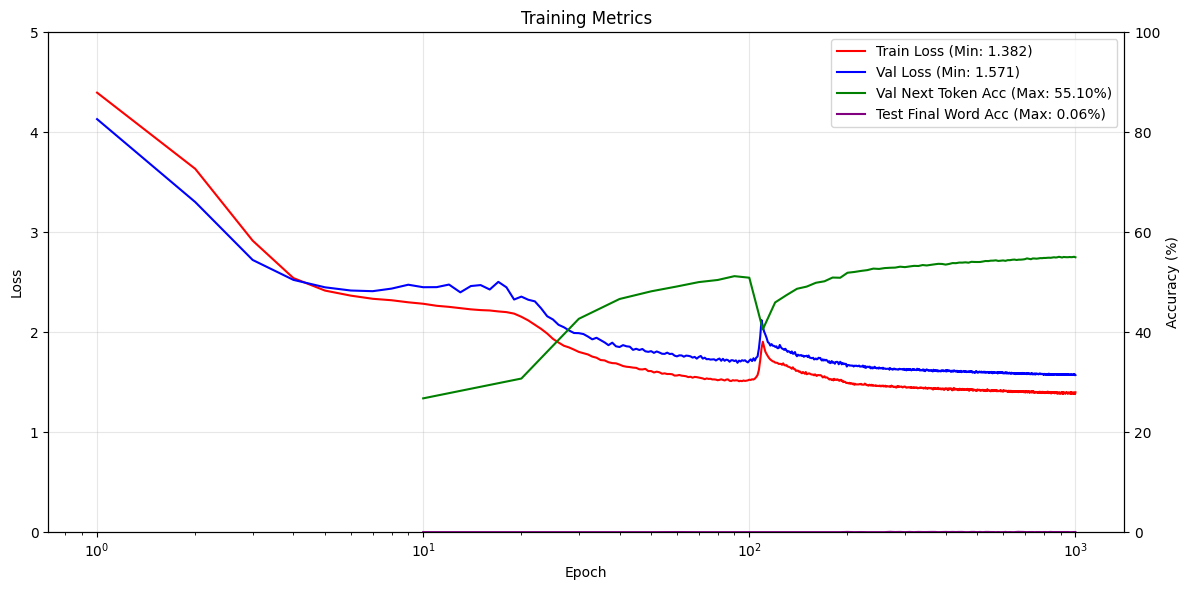

In [2]:
graphModel("transformerTinyChar.csv", 5)

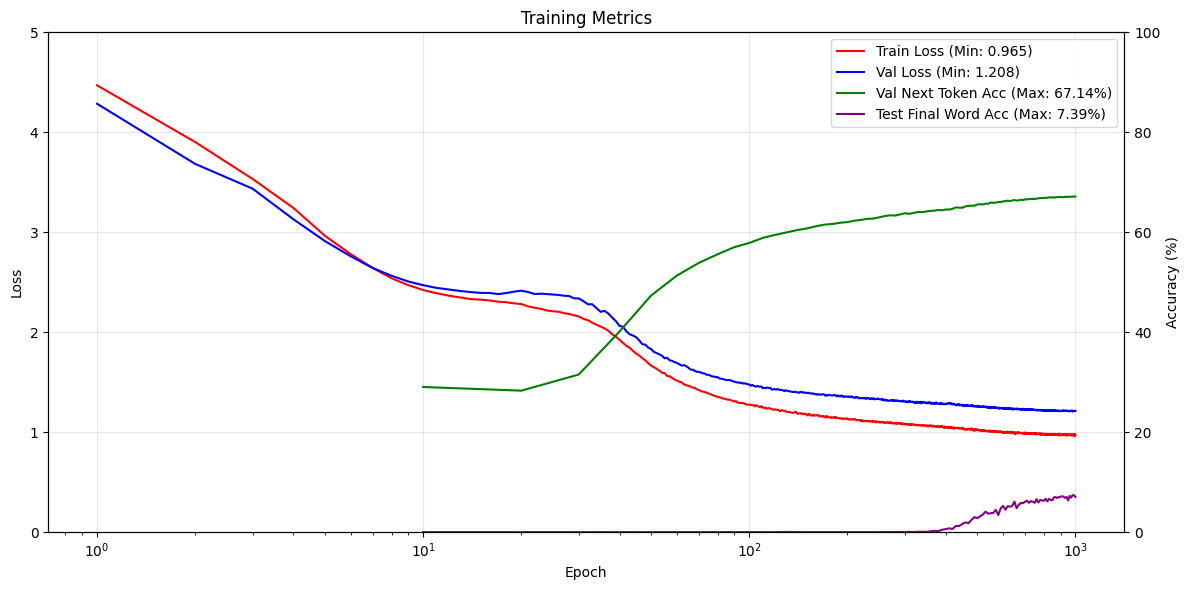

In [3]:
graphModel("transformerSmallChar.csv", 5)

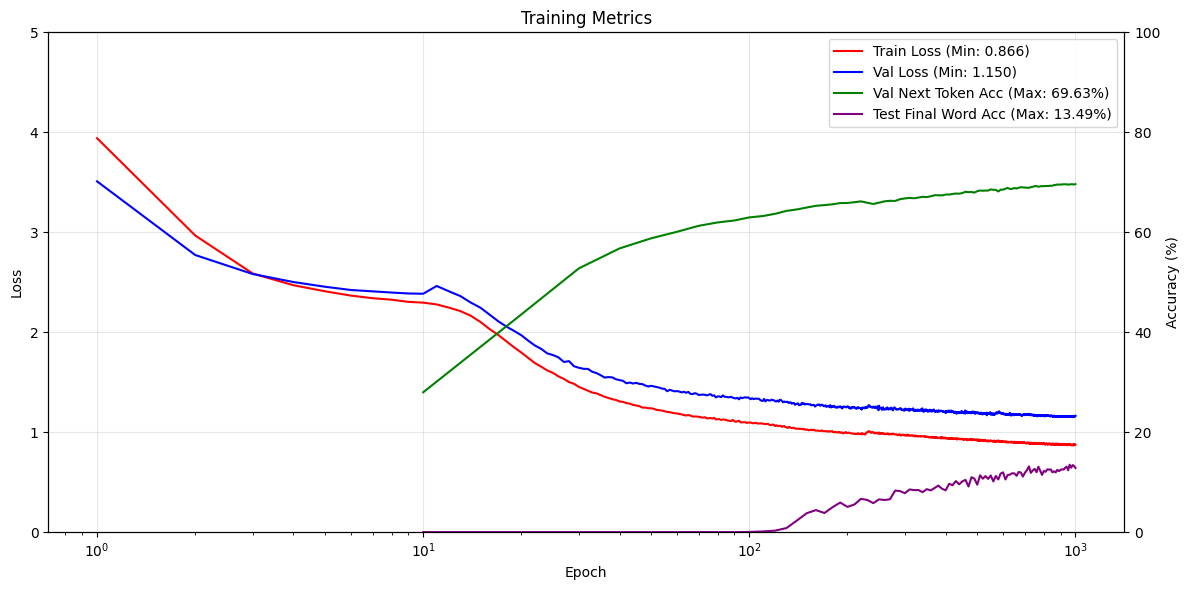

In [7]:
graphModel("transformerMediumChar.csv", 5)

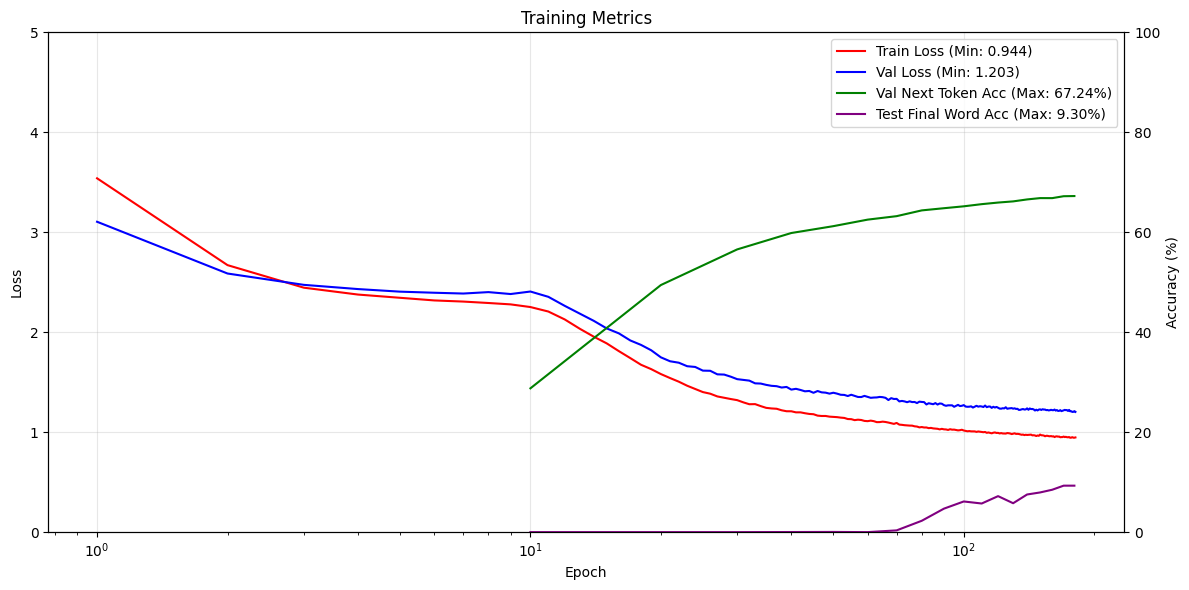

In [15]:
graphModel("transformerLargeChar.csv", 5)

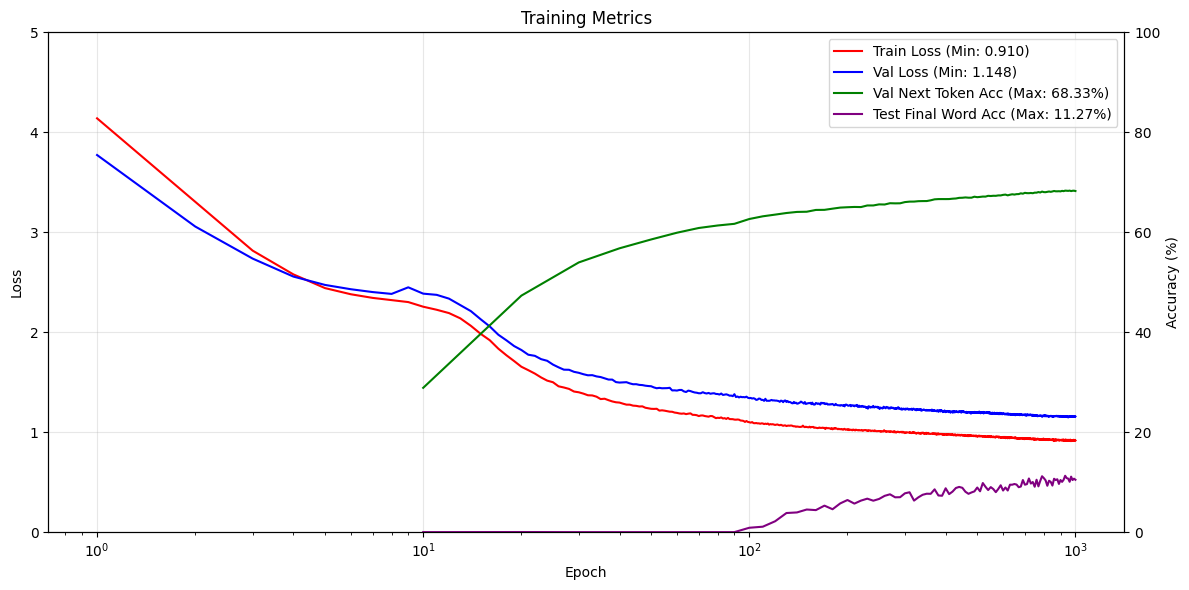

In [5]:
graphModel("transformerSmallCharOld.csv", 5)